# Part 0 — Import Packages 

In [3]:
# import necessary libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
  
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.svm import SVC 
from sklearn.metrics import ( 
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_curve, roc_auc_score 
) 
  
%matplotlib inline 
sns.set_style('whitegrid') 
pd.set_option('display.max_columns', None) 

 # Part 1 — Load & Explore the Data 

In [4]:
# Task 1 — Load the dataset and inspect its shape, columns, and data types. 

df = pd.read_csv('titanic.csv') 
print('Shape:', df.shape) 
df.head() 
 

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# to check the data types and null values in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# Task 2 — Get summary statistics for the numeric columns. 
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Task 3 — Check for missing values in every column. 
df.isnull().sum().sort_values(ascending=False) 

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

> **Observation:** `Cabin` is missing most of its values, `Age` is missing roughly 20%, and `Embarked` is missing just 2 values. `Cabin` will be dropped, `Age` will be imputed with median values, and `Embarked` will be filled with its mode.

C:\Users\HP\AppData\Local\Temp\ipykernel_27712\3862615853.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['#C0392B', '#2E86C1'])


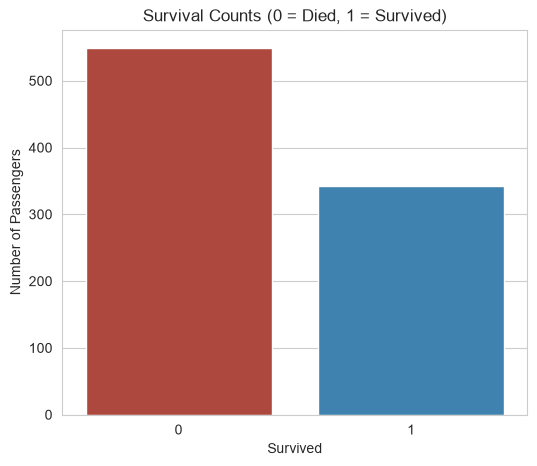

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [8]:
# Task 4 — Visualize the target variable: how many passengers survived vs. didn't?

plt.figure(figsize=(6, 5)) 
sns.countplot(x='Survived', data=df, palette=['#C0392B', '#2E86C1']) 
plt.title('Survival Counts (0 = Died, 1 = Survived)') 
plt.xlabel('Survived') 
plt.ylabel('Number of Passengers') 
plt.show() 
  
print(df['Survived'].value_counts(normalize=True).round(3)) 

**Observation:**  About 62% of passengers in this dataset did not survive and 38% did — the 
classes are imbalanced but not severely, so accuracy alone will still be informative, though 
we'll rely on precision/recall/F1 too for a fuller picture. 

C:\Users\HP\AppData\Local\Temp\ipykernel_27712\3796729387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_27712\3796729387.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Set2')


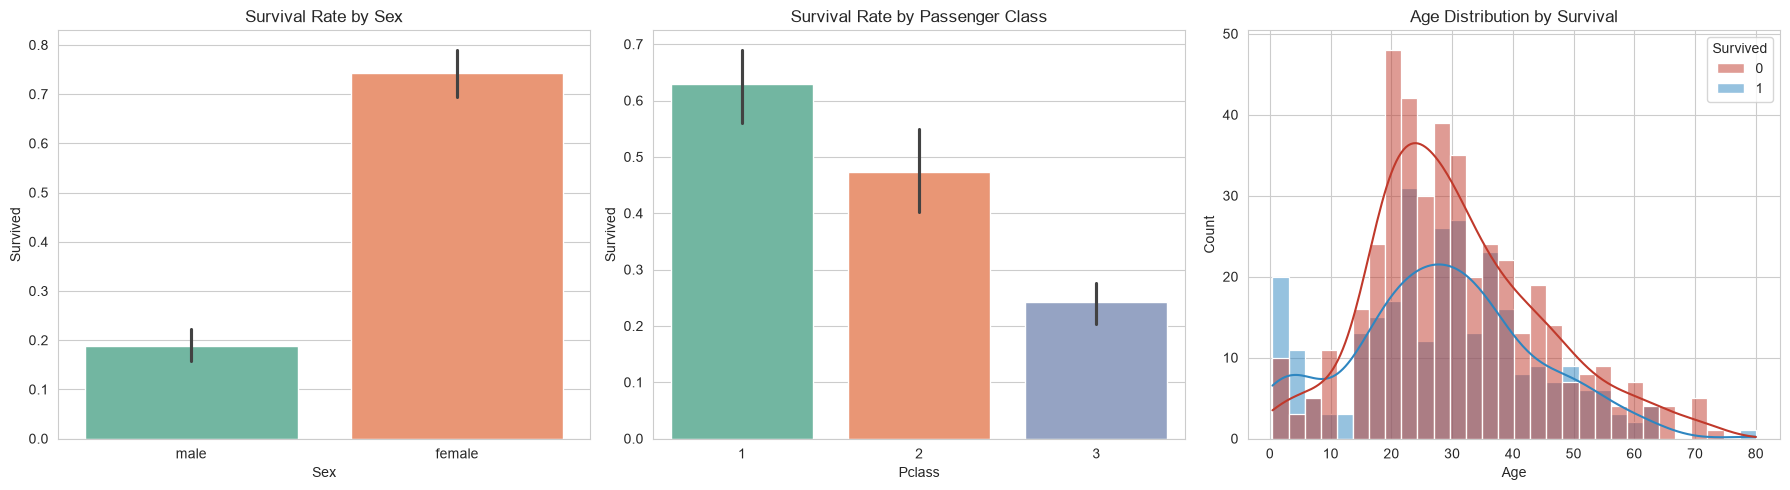

In [9]:
# Task 5 — Explore how survival relates to Sex, Pclass, and Age. 

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='Set2') 
axes[0].set_title('Survival Rate by Sex') 
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Set2') 
axes[1].set_title('Survival Rate by Passenger Class') 
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[2], 
palette=['#C0392B', '#2E86C1']) 
axes[2].set_title('Age Distribution by Survival') 
  
plt.tight_layout() 
plt.show() 

**Observation:**  Women had a much higher survival rate than men (the "women and children 
first" evacuation policy), and 1st class passengers survived at a noticeably higher rate than 
2nd or 3rd class — likely reflecting cabin location and lifeboat access. Age alone shows a 
less dramatic split, though very young children show a slightly better survival rate. 

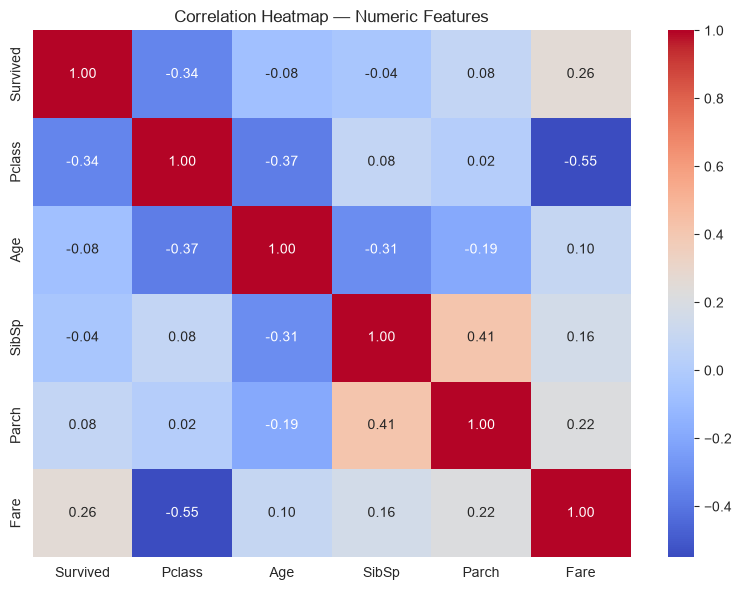

In [10]:
# Task 6 — Correlation heatmap of the numeric features. 

plt.figure(figsize=(8, 6)) 
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']] 
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f') 
plt.title('Correlation Heatmap — Numeric Features') 
plt.tight_layout() 
plt.show() 

# Part 2 — Data Cleaning & Feature Engineering

In [11]:
# Task 1 — Fill missing Age values with the median age, and missing Embarked values with the most common port. 

df['Age'] = df['Age'].fillna(df['Age'].median()) 
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 
print('Remaining missing Age:', df['Age'].isnull().sum()) 
print('Remaining missing Embarked:', df['Embarked'].isnull().sum()) 

Remaining missing Age: 0
Remaining missing Embarked: 0
